In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import time
import copy
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Dirichlet

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

with open(f"{CONFIGS_DIR}/feature_columns.json", "r") as f:
    feature_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
SEED = master_cfg["seed"]
FEATURE_COLS = feature_cfg["feature_columns"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRANSACTION_COST = 0.001

# LSTM config
HIDDEN_DIM = 128
LSTM_NUM_LAYERS = 1
LSTM_DROPOUT = 0.0

# PPO / training config
LR = 3e-4
WEIGHT_DECAY = 1e-5

GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.001
MAX_GRAD_NORM = 0.5

TRAIN_EPOCHS = 60
PPO_UPDATES_PER_EPOCH = 10
MINIBATCH_SIZE = 128

DIRICHLET_CONC_MIN = 5.0
DIRICHLET_CONC_MAX = 200.0

RUN_NAME = "lstm_ppo_10y"
MODEL_DIR = f"{OUTPUTS_MODEL_DIR}/{RUN_NAME}"
os.makedirs(MODEL_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)
print("N_FEATURES:", len(FEATURE_COLS))
print("MODEL_DIR:", MODEL_DIR)

DEVICE: cpu
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20
N_FEATURES: 13
MODEL_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/lstm_ppo_10y


In [5]:
# ============================================================
# CELL 04 — Load raw 10Y tensor bundle
# ============================================================

bundle_10y = np.load(f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz", allow_pickle=True)

X_raw = bundle_10y["X"].astype(np.float32)
y = bundle_10y["y"].astype(np.float32)
dates = pd.to_datetime(bundle_10y["dates"])
splits = bundle_10y["splits"]

print("X_raw:", X_raw.shape)
print("y:", y.shape)
print("dates:", dates.shape)
print("splits:", splits.shape)
print("unique splits:", np.unique(splits, return_counts=True))

X_raw: (2476, 20, 5, 13)
y: (2476, 5)
dates: (2476,)
splits: (2476,)
unique splits: (array(['test', 'train', 'val'], dtype='<U5'), array([ 501, 1472,  503]))


In [6]:
# ============================================================
# CELL 05 — Standardize 10Y with TRAIN only
# ============================================================

train_mask = (splits == "train")
val_mask = (splits == "val")
test_mask = (splits == "test")

scaler = StandardScaler()
train_flat = X_raw[train_mask].reshape(-1, X_raw.shape[-1])
scaler.fit(train_flat)

def apply_scaler_to_4d_tensor(X_4d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    original_shape = X_4d.shape
    flat = X_4d.reshape(-1, original_shape[-1])
    flat_scaled = scaler.transform(flat)
    return flat_scaled.reshape(original_shape).astype(np.float32)

X_scaled = apply_scaler_to_4d_tensor(X_raw, scaler)

print("X_scaled:", X_scaled.shape)
print("Train mean approx:", float(X_scaled[train_mask].mean()))
print("Train std approx:", float(X_scaled[train_mask].std()))

X_scaled: (2476, 20, 5, 13)
Train mean approx: 7.017001424358682e-10
Train std approx: 1.0000001192092896


In [7]:
# ============================================================
# CELL 06 — Split data
# ============================================================

X_train = X_scaled[train_mask]
y_train = y[train_mask]
dates_train = np.array(dates[train_mask].astype(str))

X_val = X_scaled[val_mask]
y_val = y[val_mask]
dates_val = np.array(dates[val_mask].astype(str))

X_test = X_scaled[test_mask]
y_test = y[test_mask]
dates_test = np.array(dates[test_mask].astype(str))

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (1472, 20, 5, 13) y_train: (1472, 5)
X_val: (503, 20, 5, 13) y_val: (503, 5)
X_test: (501, 20, 5, 13) y_test: (501, 5)


In [8]:
# ============================================================
# CELL 07 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.lookback = self.X.shape[1]
        self.n_assets = self.X.shape[2]
        self.n_features = self.X.shape[3]

        self.reset()

    def reset(self) -> np.ndarray:
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        if len(action) != self.n_assets:
            raise ValueError(f"Action length {len(action)} != n_assets {self.n_assets}")

        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "asset_returns": r_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(next_state=next_state, reward=float(reward), done=self.done, info=info)

In [9]:
# ============================================================
# CELL 08 — LSTM actor-critic
# ============================================================

class LSTMEncoder(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        hidden_dim: int,
        num_layers: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.lookback = lookback
        self.n_assets = n_assets
        self.n_features = n_features
        self.input_dim = n_assets * n_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.input_proj = nn.Linear(self.input_dim, hidden_dim)

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.post = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)
        x = self.input_proj(x)
        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        h_last = self.post(h_last)
        return h_last


class LSTMActorCritic(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        hidden_dim: int,
        num_layers: int = 1,
        dropout: float = 0.0,
        conc_min: float = 5.0,
        conc_max: float = 200.0,
    ):
        super().__init__()

        self.n_assets = n_assets
        self.conc_min = conc_min
        self.conc_max = conc_max

        self.encoder = LSTMEncoder(
            lookback=lookback,
            n_assets=n_assets,
            n_features=n_features,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )

        self.actor_logits = nn.Linear(hidden_dim, n_assets)
        self.actor_concentration = nn.Linear(hidden_dim, 1)
        self.critic = nn.Linear(hidden_dim, 1)

    def _get_shared(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def get_policy_dist(self, x: torch.Tensor):
        h = self._get_shared(x)

        logits = self.actor_logits(h)
        mean_weights = torch.softmax(logits, dim=-1)

        raw_conc = self.actor_concentration(h)
        conc_scalar = torch.sigmoid(raw_conc)
        conc_scalar = self.conc_min + (self.conc_max - self.conc_min) * conc_scalar
        conc_scalar = conc_scalar.squeeze(-1)

        alpha = mean_weights * conc_scalar.unsqueeze(-1)
        alpha = torch.clamp(alpha, min=1e-4)

        dist = Dirichlet(alpha)
        return dist, mean_weights, alpha

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        h = self._get_shared(x)
        v = self.critic(h).squeeze(-1)
        return v

    def act(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        action = dist.rsample()
        log_prob = dist.log_prob(action)
        value = self.get_value(x)
        entropy = dist.entropy()
        return action, log_prob, value, entropy, mean_weights, alpha

    def act_deterministic(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        value = self.get_value(x)
        return mean_weights, value, alpha

In [10]:
# ============================================================
# CELL 09 — PPO helpers
# ============================================================

def compute_gae(rewards, values, dones, gamma, gae_lambda):
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    last_adv = 0.0

    for t in reversed(range(T)):
        next_value = 0.0 if t == T - 1 else values[t + 1]
        next_nonterminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_adv = delta + gamma * gae_lambda * next_nonterminal * last_adv
        advantages[t] = last_adv

    returns = advantages + values
    return advantages.astype(np.float32), returns.astype(np.float32)


def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    return (adv - adv.mean()) / (adv.std() + 1e-8)


def collect_rollout(model: nn.Module, env: PortfolioEnv, device: str):
    model.eval()

    states, actions, log_probs, rewards, dones, values, infos = [], [], [], [], [], [], []

    state = env.reset()

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, log_prob_t, value_t, entropy_t, mean_weights_t, alpha_t = model.act(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        states.append(state)
        actions.append(action)
        log_probs.append(float(log_prob_t.item()))
        rewards.append(float(result.reward))
        dones.append(float(result.done))
        values.append(float(value_t.item()))
        infos.append(result.info)

        if result.done:
            break

        state = result.next_state

    rollout = {
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32),
        "log_probs": np.asarray(log_probs, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "values": np.asarray(values, dtype=np.float32),
        "infos": infos,
    }

    advantages, returns = compute_gae(
        rewards=rollout["rewards"],
        values=rollout["values"],
        dones=rollout["dones"],
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
    )

    rollout["advantages"] = advantages
    rollout["returns"] = returns
    return rollout


def ppo_update(model, optimizer, rollout, device: str):
    model.train()

    states = torch.tensor(rollout["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(rollout["actions"], dtype=torch.float32, device=device)
    old_log_probs = torch.tensor(rollout["log_probs"], dtype=torch.float32, device=device)
    returns = torch.tensor(rollout["returns"], dtype=torch.float32, device=device)
    advantages = torch.tensor(rollout["advantages"], dtype=torch.float32, device=device)
    advantages = normalize_advantages(advantages)

    n_samples = states.size(0)
    idxs = np.arange(n_samples)
    update_logs = []

    for _ in range(PPO_UPDATES_PER_EPOCH):
        np.random.shuffle(idxs)

        for start in range(0, n_samples, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_idx = idxs[start:end]

            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            dist, mean_weights, alpha = model.get_policy_dist(mb_states)
            new_log_probs = dist.log_prob(mb_actions)
            entropy = dist.entropy().mean()
            values = model.get_value(mb_states)

            ratio = torch.exp(new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            value_loss = ((values - mb_returns) ** 2).mean()

            total_loss = actor_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            update_logs.append({
                "actor_loss": float(actor_loss.item()),
                "value_loss": float(value_loss.item()),
                "entropy": float(entropy.item()),
            })

    return pd.DataFrame(update_logs)

In [11]:
# ============================================================
# CELL 10 — Evaluation helpers
# ============================================================

def compute_rollout_metrics(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }


def evaluate_policy(model, X, y, dates, device: str, reward_mode: str = "cost_aware"):
    model.eval()

    env = PortfolioEnv(
        X=X,
        y=y,
        dates=dates,
        transaction_cost=TRANSACTION_COST,
        reward_mode=reward_mode,
    )

    state = env.reset()
    rows = []

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, value_t, alpha_t = model.act_deterministic(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        row = {
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "reward_no_cost": result.info["reward_no_cost"],
            "reward_cost_aware": result.info["reward_cost_aware"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        }

        for i, asset in enumerate(ASSETS):
            row[f"w_{asset}"] = float(result.info["weights"][i])

        rows.append(row)

        if result.done:
            break

        state = result.next_state

    df_rollout = pd.DataFrame(rows)
    metrics = compute_rollout_metrics(df_rollout)
    return df_rollout, metrics

In [12]:
# ============================================================
# CELL 11 — Build model and optimizer
# ============================================================

model = LSTMActorCritic(
    lookback=LOOKBACK,
    n_assets=len(ASSETS),
    n_features=len(FEATURE_COLS),
    hidden_dim=HIDDEN_DIM,
    num_layers=LSTM_NUM_LAYERS,
    dropout=LSTM_DROPOUT,
    conc_min=DIRICHLET_CONC_MIN,
    conc_max=DIRICHLET_CONC_MAX,
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

print(model)

LSTMActorCritic(
  (encoder): LSTMEncoder(
    (input_proj): Linear(in_features=65, out_features=128, bias=True)
    (lstm): LSTM(128, 128, batch_first=True)
    (post): Sequential(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (1): GELU(approximate='none')
    )
  )
  (actor_logits): Linear(in_features=128, out_features=5, bias=True)
  (actor_concentration): Linear(in_features=128, out_features=1, bias=True)
  (critic): Linear(in_features=128, out_features=1, bias=True)
)


In [13]:
# ============================================================
# CELL 12 — One dry rollout before training
# ============================================================

train_env = PortfolioEnv(
    X=X_train,
    y=y_train,
    dates=dates_train,
    transaction_cost=TRANSACTION_COST,
    reward_mode="cost_aware",
)

dry_rollout = collect_rollout(model, train_env, DEVICE)

print("dry states:", dry_rollout["states"].shape)
print("dry actions:", dry_rollout["actions"].shape)
print("dry rewards:", dry_rollout["rewards"].shape)
print("dry returns:", dry_rollout["returns"].shape)
print("dry advantages:", dry_rollout["advantages"].shape)

dry states: (1472, 20, 5, 13)
dry actions: (1472, 5)
dry rewards: (1472,)
dry returns: (1472,)
dry advantages: (1472,)


In [15]:
# ============================================================
# CELL 13 — Training loop
# ============================================================

history_rows = []

best_val_cumret = -1e18
best_state_dict = None
best_epoch = -1

start_time = time.time()

for epoch in range(1, TRAIN_EPOCHS + 1):
    train_env = PortfolioEnv(
        X=X_train,
        y=y_train,
        dates=dates_train,
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )

    rollout = collect_rollout(model, train_env, DEVICE)
    update_df = ppo_update(model, optimizer, rollout, DEVICE)

    _, train_metrics = evaluate_policy(model, X_train, y_train, dates_train, DEVICE)
    _, val_metrics = evaluate_policy(model, X_val, y_val, dates_val, DEVICE)

    history_rows.append({
        "epoch": epoch,
        "train_cumulative_return": train_metrics["cumulative_return"],
        "train_sharpe": train_metrics["sharpe_approx"],
        "train_max_drawdown": train_metrics["max_drawdown"],
        "train_avg_turnover": train_metrics["avg_turnover"],
        "val_cumulative_return": val_metrics["cumulative_return"],
        "val_sharpe": val_metrics["sharpe_approx"],
        "val_max_drawdown": val_metrics["max_drawdown"],
        "val_avg_turnover": val_metrics["avg_turnover"],
        "actor_loss_mean": update_df["actor_loss"].mean(),
        "value_loss_mean": update_df["value_loss"].mean(),
        "entropy_mean": update_df["entropy"].mean(),
    })

    if val_metrics["cumulative_return"] > best_val_cumret:
        best_val_cumret = val_metrics["cumulative_return"]
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train CR={train_metrics['cumulative_return']:.4f} | "
            f"Val CR={val_metrics['cumulative_return']:.4f} | "
            f"Val Sharpe={val_metrics['sharpe_approx']:.4f} | "
            f"Best Val CR={best_val_cumret:.4f} @ epoch {best_epoch}"
        )

elapsed = time.time() - start_time
history_df = pd.DataFrame(history_rows)

print(f"\nTraining completed in {elapsed/60:.2f} minutes")
print("Best epoch:", best_epoch)
print("Best val cumulative return:", best_val_cumret)

Epoch 001 | Train CR=2.1517 | Val CR=-0.1580 | Val Sharpe=-0.1080 | Best Val CR=-0.1580 @ epoch 1
Epoch 005 | Train CR=2.2248 | Val CR=-0.1653 | Val Sharpe=-0.1204 | Best Val CR=-0.1489 @ epoch 3
Epoch 010 | Train CR=2.2739 | Val CR=-0.1776 | Val Sharpe=-0.1210 | Best Val CR=-0.1466 @ epoch 8
Epoch 015 | Train CR=2.4469 | Val CR=-0.1936 | Val Sharpe=-0.1452 | Best Val CR=-0.1466 @ epoch 8
Epoch 020 | Train CR=2.3373 | Val CR=-0.1869 | Val Sharpe=-0.1137 | Best Val CR=-0.1466 @ epoch 8
Epoch 025 | Train CR=2.1124 | Val CR=-0.1870 | Val Sharpe=-0.1129 | Best Val CR=-0.1466 @ epoch 8
Epoch 030 | Train CR=2.1305 | Val CR=-0.1749 | Val Sharpe=-0.0669 | Best Val CR=-0.1466 @ epoch 8
Epoch 035 | Train CR=2.0888 | Val CR=-0.1972 | Val Sharpe=-0.1132 | Best Val CR=-0.1466 @ epoch 8
Epoch 040 | Train CR=2.2115 | Val CR=-0.1916 | Val Sharpe=-0.0939 | Best Val CR=-0.1466 @ epoch 8
Epoch 045 | Train CR=2.1318 | Val CR=-0.1853 | Val Sharpe=-0.0652 | Best Val CR=-0.1466 @ epoch 8
Epoch 050 | Train CR

In [16]:
# ============================================================
# CELL 14 — Save training history
# ============================================================

history_df.to_csv(f"{MODEL_DIR}/training_history.csv", index=False)
print("Saved:", f"{MODEL_DIR}/training_history.csv")
display(history_df.tail())

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/lstm_ppo_10y/training_history.csv


,epoch,train_cumulative_return,train_sharpe,train_max_drawdown,train_avg_turnover,val_cumulative_return,val_sharpe,val_max_drawdown,val_avg_turnover,actor_loss_mean,value_loss_mean,entropy_mean
55,56,2.268590,1.281814,-0.251006,0.253878,-0.194249,-0.085615,-0.339410,0.236319,-0.085053,0.000745,-9.289555
56,57,2.313830,1.291945,-0.252199,0.253640,-0.200660,-0.100843,-0.342427,0.238257,-0.080710,0.000754,-9.303143
57,58,2.286538,1.284350,-0.251863,0.255204,-0.202512,-0.102036,-0.344702,0.239793,-0.084098,0.000771,-9.313947
58,59,2.293958,1.288046,-0.252889,0.257615,-0.206385,-0.107715,-0.346791,0.241995,-0.091022,0.000753,-9.313661
59,60,2.367498,1.304955,-0.251031,0.259054,-0.197385,-0.083318,-0.342305,0.242898,-0.086007,0.000826,-9.320443


In [17]:
# ============================================================
# CELL 15 — Load best model
# ============================================================

assert best_state_dict is not None, "best_state_dict is None"

model.load_state_dict(best_state_dict)
torch.save(model.state_dict(), f"{MODEL_DIR}/best_model.pt")

print("Saved best model:", f"{MODEL_DIR}/best_model.pt")
print("Best epoch:", best_epoch)

Saved best model: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/lstm_ppo_10y/best_model.pt
Best epoch: 8


In [18]:
# ============================================================
# CELL 16 — Final evaluation on train / val / test
# ============================================================

train_rollout_df, train_metrics = evaluate_policy(model, X_train, y_train, dates_train, DEVICE)
val_rollout_df, val_metrics = evaluate_policy(model, X_val, y_val, dates_val, DEVICE)
test_rollout_df, test_metrics = evaluate_policy(model, X_test, y_test, dates_test, DEVICE)

summary_df = pd.DataFrame([
    {"split": "train", **train_metrics},
    {"split": "val", **val_metrics},
    {"split": "test", **test_metrics},
])

display(summary_df)

,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,train,1472,3.217416,2.217416,0.001046,0.013833,1.200290,-0.268693,0.155929,0.229527,0.000156
1,val,503,0.853420,-0.146580,-0.000055,0.014614,-0.059377,-0.313768,0.153493,0.077207,0.000153
2,test,501,1.602773,0.602773,0.001135,0.009603,1.876290,-0.107737,0.146698,0.073496,0.000147


In [19]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=summary_df)

https://docs.google.com/spreadsheets/d/1DJwwgVuelnO2K41-s_SAeeKfh6Drv7sW6pwzTCz1yqA/edit#gid=0


In [20]:
# ============================================================
# CELL 17 — Save rollout outputs
# ============================================================

train_rollout_df.to_csv(f"{MODEL_DIR}/train_rollout_best.csv", index=False)
val_rollout_df.to_csv(f"{MODEL_DIR}/val_rollout_best.csv", index=False)
test_rollout_df.to_csv(f"{MODEL_DIR}/test_rollout_best.csv", index=False)
summary_df.to_csv(f"{MODEL_DIR}/summary_metrics_best.csv", index=False)

print("Saved rollout and summary files.")

Saved rollout and summary files.


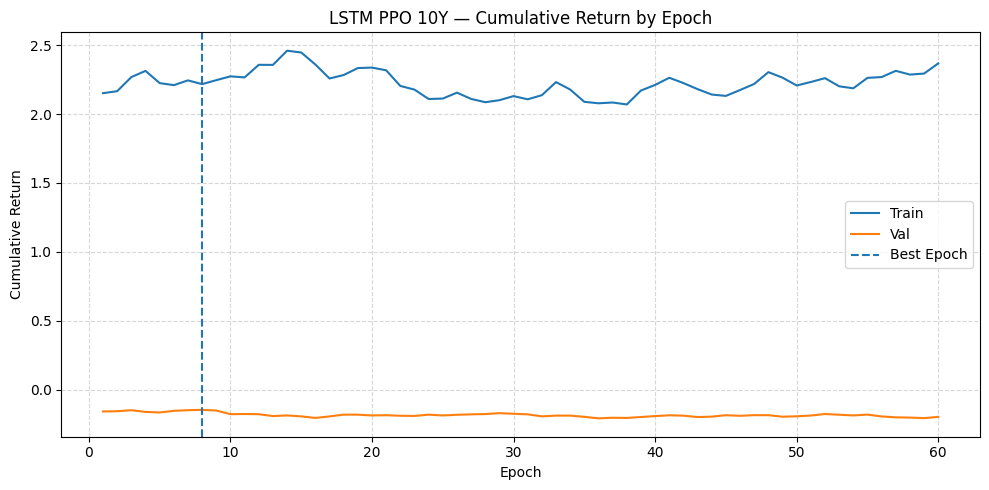

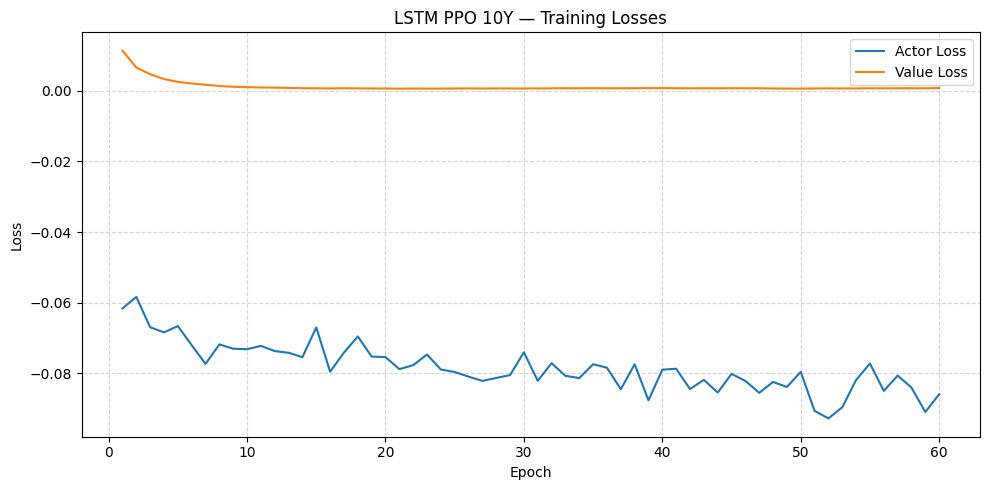

In [21]:
# ============================================================
# CELL 18 — Plot training curves
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_cumulative_return"], label="Train")
plt.plot(history_df["epoch"], history_df["val_cumulative_return"], label="Val")
plt.axvline(best_epoch, linestyle="--", label="Best Epoch")
plt.title("LSTM PPO 10Y — Cumulative Return by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["actor_loss_mean"], label="Actor Loss")
plt.plot(history_df["epoch"], history_df["value_loss_mean"], label="Value Loss")
plt.title("LSTM PPO 10Y — Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

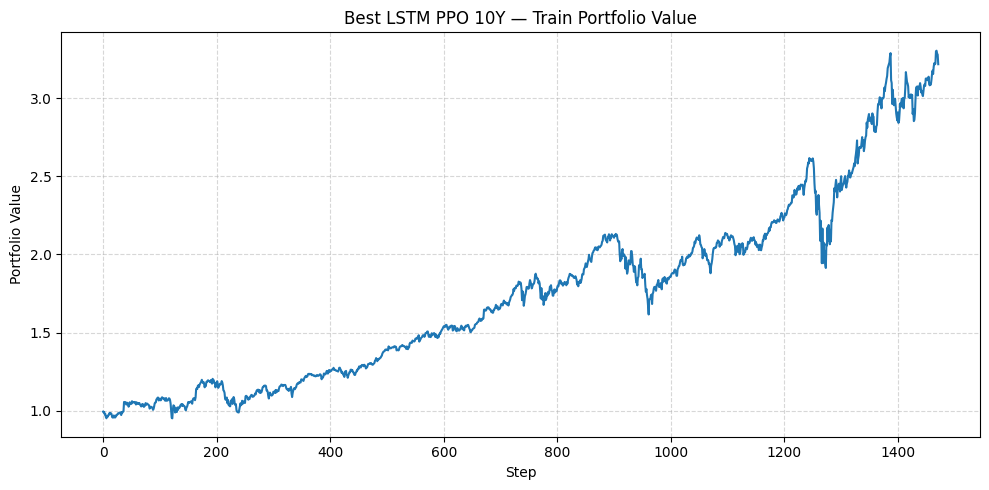

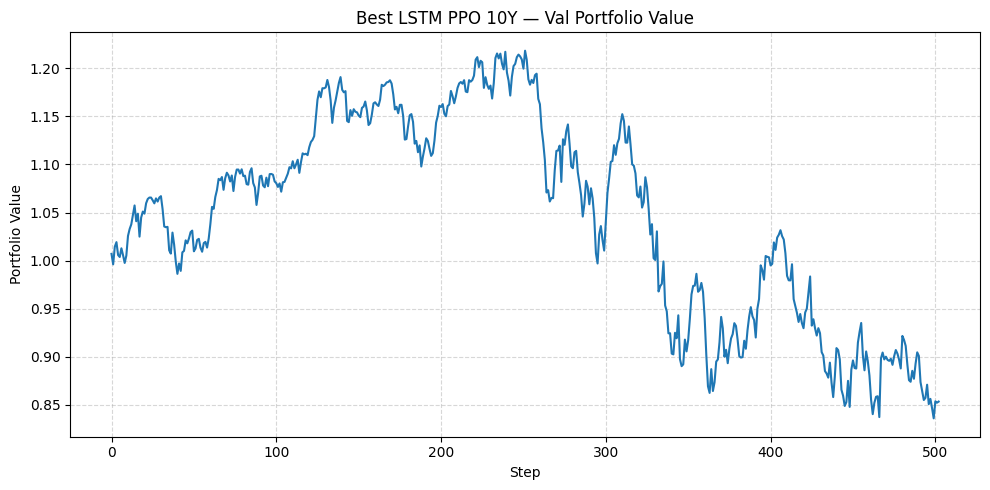

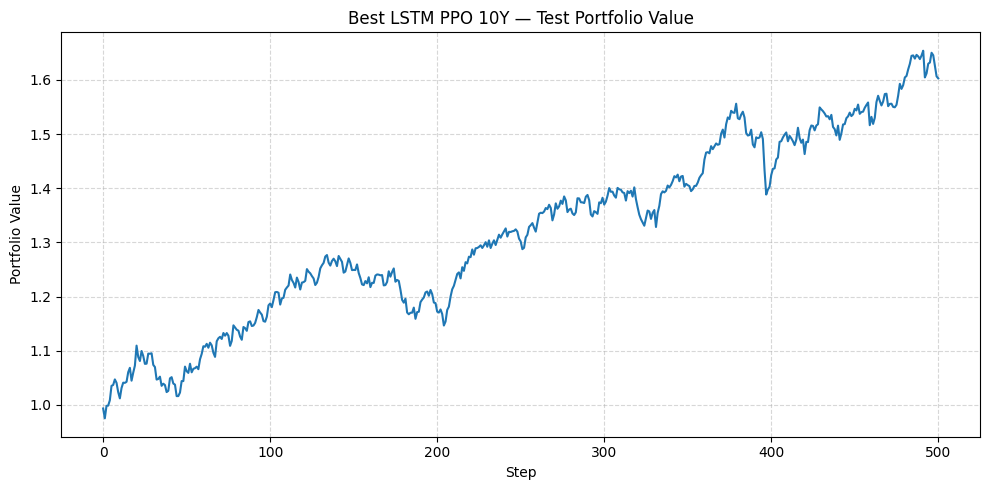

In [22]:
# ============================================================
# CELL 19 — Plot best portfolio value curves
# ============================================================

def plot_rollout_pv(df_rollout: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 5))
    plt.plot(df_rollout["portfolio_value"].values)
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Portfolio Value")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_rollout_pv(train_rollout_df, "Best LSTM PPO 10Y — Train Portfolio Value")
plot_rollout_pv(val_rollout_df, "Best LSTM PPO 10Y — Val Portfolio Value")
plot_rollout_pv(test_rollout_df, "Best LSTM PPO 10Y — Test Portfolio Value")

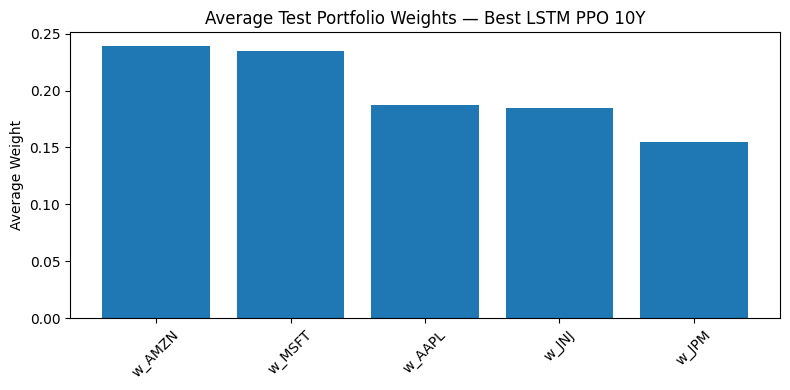

,avg_weight
w_AMZN,0.239235
w_MSFT,0.234365
w_AAPL,0.187621
w_JNJ,0.184287
w_JPM,0.154492


In [23]:
# ============================================================
# CELL 20 — Plot average portfolio weights on test
# ============================================================

weight_cols = [f"w_{asset}" for asset in ASSETS]
avg_weights_test = test_rollout_df[weight_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(avg_weights_test.index, avg_weights_test.values)
plt.title("Average Test Portfolio Weights — Best LSTM PPO 10Y")
plt.ylabel("Average Weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(avg_weights_test.to_frame("avg_weight"))

In [24]:
# ============================================================
# CELL 21 — Save run config
# ============================================================

run_config = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "device": DEVICE,
    "lookback": LOOKBACK,
    "n_assets": len(ASSETS),
    "n_features": len(FEATURE_COLS),
    "transaction_cost": TRANSACTION_COST,
    "hidden_dim": HIDDEN_DIM,
    "lstm_num_layers": LSTM_NUM_LAYERS,
    "lstm_dropout": LSTM_DROPOUT,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "gamma": GAMMA,
    "gae_lambda": GAE_LAMBDA,
    "clip_eps": CLIP_EPS,
    "value_coef": VALUE_COEF,
    "entropy_coef": ENTROPY_COEF,
    "max_grad_norm": MAX_GRAD_NORM,
    "train_epochs": TRAIN_EPOCHS,
    "ppo_updates_per_epoch": PPO_UPDATES_PER_EPOCH,
    "minibatch_size": MINIBATCH_SIZE,
    "dirichlet_conc_min": DIRICHLET_CONC_MIN,
    "dirichlet_conc_max": DIRICHLET_CONC_MAX,
    "best_epoch": int(best_epoch),
    "best_val_cumulative_return": float(best_val_cumret),
}

with open(f"{MODEL_DIR}/run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved:", f"{MODEL_DIR}/run_config.json")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/lstm_ppo_10y/run_config.json


In [25]:
# ============================================================
# CELL 22 — Final sanity checks
# ============================================================

required_files = [
    f"{MODEL_DIR}/best_model.pt",
    f"{MODEL_DIR}/training_history.csv",
    f"{MODEL_DIR}/summary_metrics_best.csv",
    f"{MODEL_DIR}/run_config.json",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

assert len(train_rollout_df) == len(X_train)
assert len(val_rollout_df) == len(X_val)
assert len(test_rollout_df) == len(X_test)

print("All LSTM PPO 10Y notebook checks passed.")

All LSTM PPO 10Y notebook checks passed.
